In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Carregar os dados
df = pd.read_csv('../../data/phishing.csv')

# Separar atributos (X) e a variável alvo (y)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Converter targets de {-1, 1} para {0, 1} (necessário para o XGBoost e ROC-AUC)
if set(y.unique()) == {-1, 1}:
    y = y.map({-1: 0, 1: 1})

# 2. Divisão 80/20 com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dados carregados e preparados com sucesso!")

Dados carregados e preparados com sucesso!


=== COMPARAÇÃO FINAL DOS MELHORES MODELOS ===
       Modelo  Accuracy  Precision   Recall  F1-Score
Random Forest  0.970602   0.970596 0.970602  0.970594
      XGBoost  0.966531   0.966574 0.966531  0.966501
          SVM  0.957938   0.958096 0.957938  0.957871


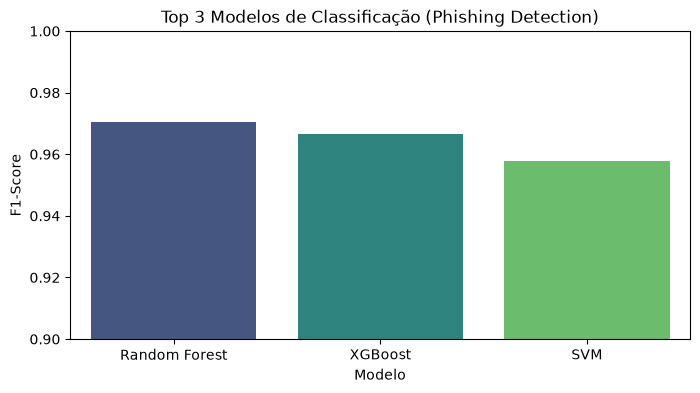

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.svm import SVC

# 1. Inicializar e Treinar os 3 Melhores Modelos
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# 2. Tabela Resumo
summary_data = [
    {
        "Modelo": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf, average='weighted'),
        "Recall": recall_score(y_test, y_pred_rf, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred_rf, average='weighted')
    },
    {
        "Modelo": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Precision": precision_score(y_test, y_pred_xgb, average='weighted'),
        "Recall": recall_score(y_test, y_pred_xgb, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred_xgb, average='weighted')
    },
    {
        "Modelo": "SVM",
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Precision": precision_score(y_test, y_pred_svm, average='weighted'),
        "Recall": recall_score(y_test, y_pred_svm, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred_svm, average='weighted')
    }
]

df_top3 = pd.DataFrame(summary_data).sort_values(by="F1-Score", ascending=False)

print("=== COMPARAÇÃO FINAL DOS MELHORES MODELOS ===")
print(df_top3.to_string(index=False))

# 3. Gráfico de Comparação
plt.figure(figsize=(8, 4))
sns.barplot(data=df_top3, x="Modelo", y="F1-Score", hue="Modelo", palette="viridis", legend=False)
plt.title("Top 3 Modelos de Classificação (Phishing Detection)")
plt.ylim(0.90, 1.0)
plt.show()

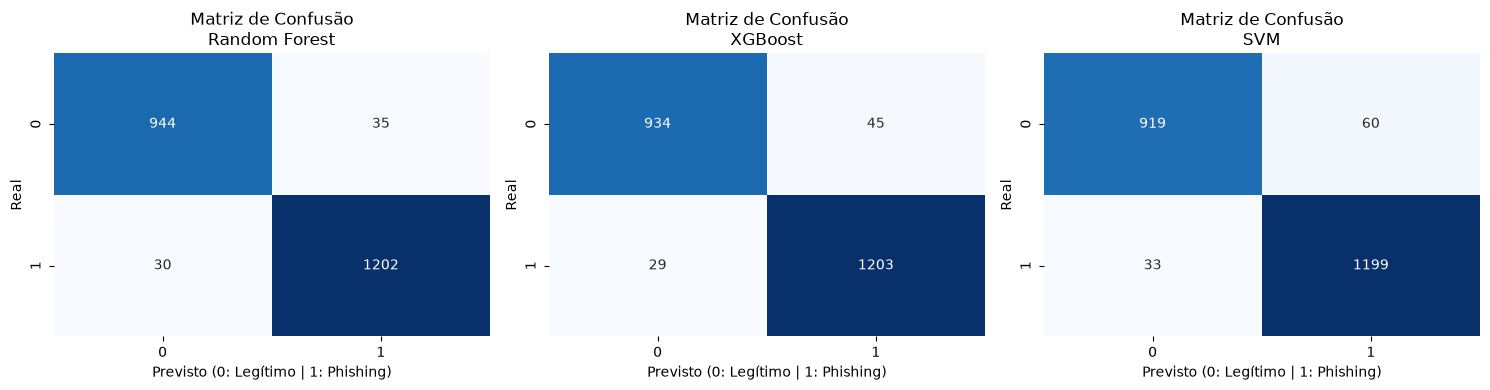

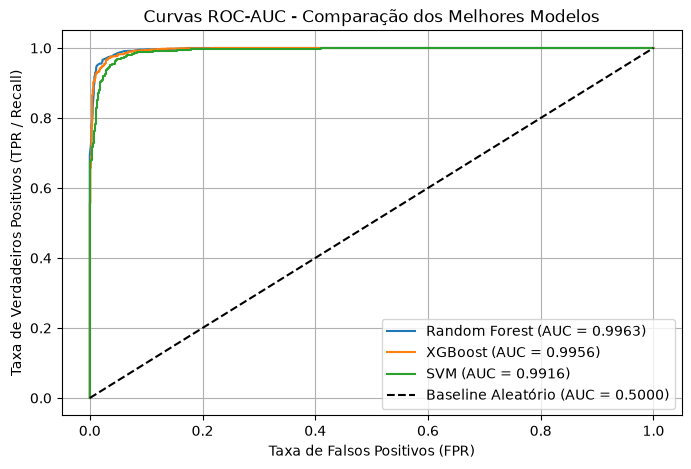

In [7]:
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

top_models = {
    "Random Forest": (rf_model, y_pred_rf),
    "XGBoost": (xgb_model, y_pred_xgb),
    "SVM": (svm_model, y_pred_svm)
}

# 1. Matrizes de Confusão
plt.figure(figsize=(15, 4))

for idx, (name, (model, y_pred)) in enumerate(top_models.items(), 1):
    plt.subplot(1, 3, idx)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusão\n{name}')
    plt.xlabel('Previsto (0: Legítimo | 1: Phishing)')
    plt.ylabel('Real')

plt.tight_layout()
plt.show()

# 2. Curvas ROC-AUC
plt.figure(figsize=(8, 5))

for name, (model, _) in top_models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)
        
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Baseline Aleatório (AUC = 0.5000)')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR / Recall)')
plt.title('Curvas ROC-AUC - Comparação dos Melhores Modelos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [8]:
from sklearn.model_selection import GridSearchCV

# 1. Análise de Overfitting / Underfitting
def eval_fit(model, name):
    f1_tr = f1_score(y_train, model.predict(X_train_scaled), average='weighted')
    f1_te = f1_score(y_test, model.predict(X_test_scaled), average='weighted')
    diff = f1_tr - f1_te
    return {
        "Modelo": name,
        "F1 (Treino)": round(f1_tr, 4),
        "F1 (Teste)": round(f1_te, 4),
        "Diferença": round(diff, 4),
        "Diagnóstico": "Ligeiro Overfitting" if diff > 0.03 else "Boa Generalização"
    }

fit_report = [
    eval_fit(rf_model, "Random Forest"),
    eval_fit(xgb_model, "XGBoost"),
    eval_fit(svm_model, "SVM")
]

print("=== DIAGNÓSTICO DE OVERFITTING / UNDERFITTING ===")
print(pd.DataFrame(fit_report).to_string(index=False))
print("\n" + "="*50 + "\n")

# 2. Otimização de Hiperparâmetros (GridSearchCV no Random Forest)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1
)

print("=== A EXECUTAR HYPERPARAMETER TUNING (Random Forest) ===")
grid.fit(X_train_scaled, y_train)

best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

print("Melhores Hiperparâmetros encontrados:")
print(grid.best_params_)
print(f"F1-Score Otimizado no Teste: {f1_score(y_test, y_pred_best, average='weighted'):.4f}")

=== DIAGNÓSTICO DE OVERFITTING / UNDERFITTING ===
       Modelo  F1 (Treino)  F1 (Teste)  Diferença       Diagnóstico
Random Forest       1.0000      0.9706     0.0294 Boa Generalização
      XGBoost       0.9762      0.9665     0.0097 Boa Generalização
          SVM       0.9587      0.9579     0.0008 Boa Generalização


=== A EXECUTAR HYPERPARAMETER TUNING (Random Forest) ===
Melhores Hiperparâmetros encontrados:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
F1-Score Otimizado no Teste: 0.9692
